# TP2 — Clasificación supervisada · Bank Marketing
72.75 Aprendizaje Automático · Defensa 07/10/26

**Cuándo opera el modelo:** antes de cada llamada, para decidir a qué clientes priorizar.

**Flujo de datos (qué se usa en cada etapa):**
`df` → split estratificado 80/20 → **train** (EDA, validación cruzada, elección de umbral, curvas de validación, ajuste) · **test** (una sola vez, punto 4).

In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd

from tp2 import config, data, evaluation as ev, models, plots

plots.setup()
pd.set_option("display.precision", 3)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 0. Dataset y split train/test

In [3]:
raw = pd.read_csv(config.DATA_RAW, sep=";")
print(f"Filas: {len(raw):,} · columnas: {raw.shape[1]} · duplicados exactos: {raw.duplicated().sum()} · NaN: {raw.isna().sum().sum()}")

df = data.load_raw()  # elimina duplicados, tipa categóricas, y -> 0/1
X_train, X_test, y_train, y_test = data.train_test(df)
df_train = X_train.assign(y=y_train)  # el EDA se hace SOLO sobre train: el test no se mira
print(f"train: {X_train.shape} · test: {X_test.shape} · % yes train/test: {y_train.mean():.3%} / {y_test.mean():.3%}")

Filas: 41,188 · columnas: 21 · duplicados exactos: 12 · NaN: 0
train: (32940, 20) · test: (8236, 20) · % yes train/test: 11.266% / 11.268%


## 1. Preprocesamiento y análisis exploratorio
El EDA se hace **sólo sobre train** para no filtrar información del test en las decisiones.
Cada subsección termina con una **decisión** que se implementa en el pipeline (`src/tp2/features.py`).

### 1.1 Estructura y valores faltantes

In [4]:
info = pd.DataFrame({
    "dtype": df_train.dtypes.astype(str),
    "n_únicos": df_train.nunique(),
    "% unknown": (df_train == "unknown").mean().mul(100).round(2),
})
info

,dtype,n_únicos,% unknown
age,int64,77,0.00
job,category,12,0.81
marital,category,4,0.21
education,category,8,4.22
default,category,3,20.82
housing,category,3,2.36
loan,category,3,2.36
contact,category,2,0.00
month,category,10,0.00
day_of_week,category,5,0.00


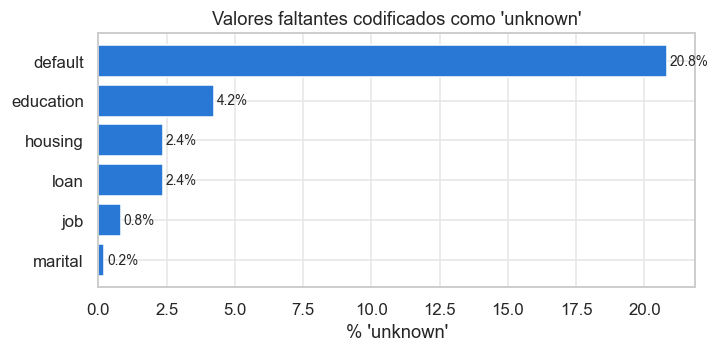

In [5]:
fig, ax = plt.subplots(figsize=(7, 3))
plots.unknown_share(df_train, config.CATEGORICAL_COLS, ax=ax)
plots.save(fig, "eda_unknown")

In [6]:
# ¿'unknown' es ruido o información? Tasa de yes por categoría en default
df_train.groupby("default", observed=True)["y"].agg(tasa_yes="mean", n="size")

,tasa_yes,n
default,,
no,0.128,26081
unknown,0.053,6857
yes,0.000,2


**Observaciones**
- No hay NaN: los faltantes están codificados como `"unknown"`. El más relevante es `default` (~21 %).
- En `default`, `unknown` tiene una tasa de yes (~5 %) muy distinta de `no` (~13 %) → **no es aleatorio, es informativo**.
- Se eliminaron 12 duplicados exactos (en `data.load_raw`).

**Decisión:** mantener `"unknown"` como **una categoría más** (no imputar ni borrar filas): imputar con la moda destruiría una señal real.

### 1.2 Balance de clases

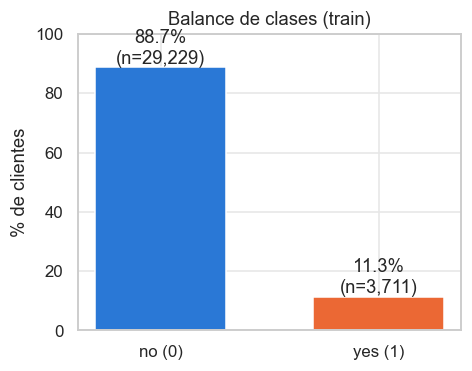

In [7]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))
plots.class_balance(y_train, ax=ax)
plots.save(fig, "eda_balance")

**Observación:** ~11.3 % de positivos → clases desbalanceadas (≈ 1:8).
Un clasificador que siempre dice "no" tendría **88.7 % de accuracy** sin servir para nada.

**Decisiones:**
- Split y k-fold **estratificados**: cada fold mantiene el 11.3 % de yes.
- **No usar accuracy**; se usan ROC-AUC y F1 (punto 2.3).
- El desbalance se maneja **eligiendo el umbral** de decisión con datos de train (clase 4), no con el 0.5 por defecto.

### 1.3 Variables numéricas

In [8]:
df_train[config.NUMERIC_COLS + ["duration"]].describe().T

,count,mean,std,min,25%,50%,75%,max
age,32940.0,40.017,10.453,17.000,32.000,38.000,47.000,98.000
campaign,32940.0,2.562,2.770,1.000,1.000,2.000,3.000,56.000
pdays,32940.0,962.617,186.555,0.000,999.000,999.000,999.000,999.000
previous,32940.0,0.174,0.499,0.000,0.000,0.000,0.000,7.000
emp.var.rate,32940.0,0.080,1.572,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,32940.0,93.576,0.579,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,32940.0,-40.510,4.629,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,32940.0,3.618,1.736,0.634,1.344,4.857,4.961,5.045
nr.employed,32940.0,5166.906,72.398,4963.600,5099.100,5191.000,5228.100,5228.100
duration,32940.0,257.743,257.498,0.000,102.000,179.000,319.000,4199.000


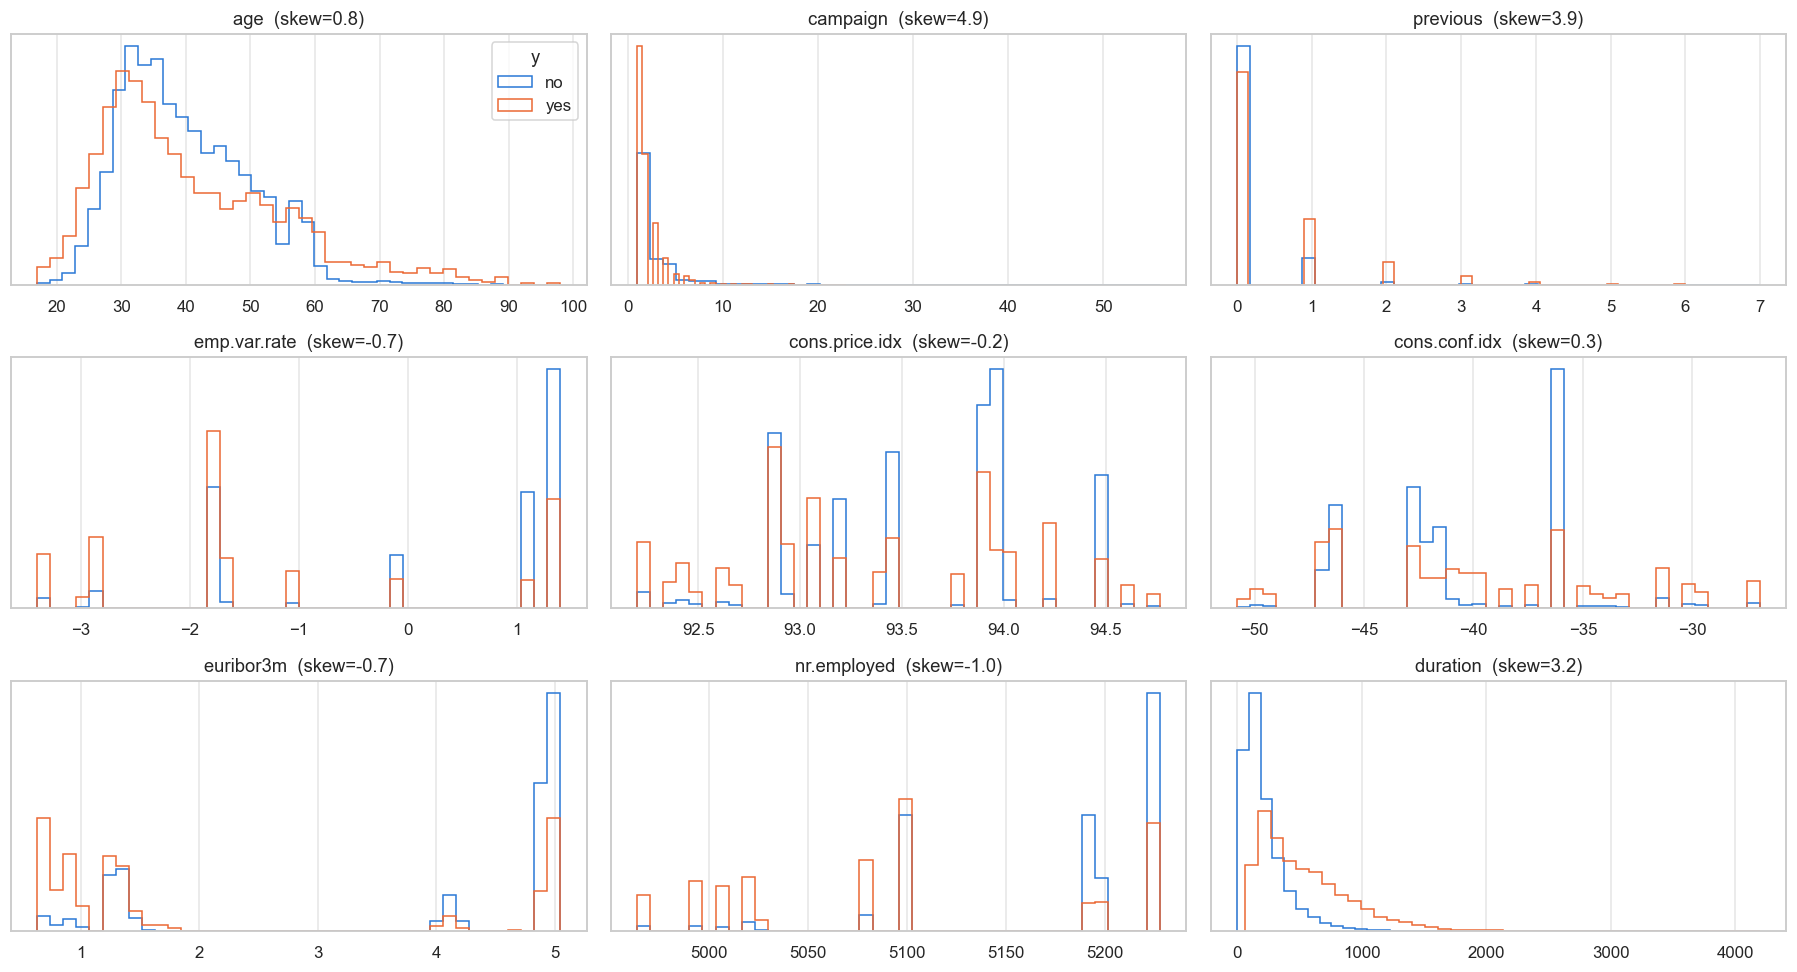

In [9]:
fig = plots.numeric_by_class(
    df_train,
    ["age", "campaign", "previous", "emp.var.rate", "cons.price.idx",
     "cons.conf.idx", "euribor3m", "nr.employed", "duration"],
)
plots.save(fig, "eda_numericas")

**Observaciones**
- **Escalas muy distintas** (`nr.employed` ~5000 vs `emp.var.rate` ~±3) → en SVM y KNN (distancias / productos internos) dominarían las variables grandes.
- `campaign` y `previous`: conteos muy asimétricos (cola larga).
- Las macroeconómicas toman **pocos valores** (indicadores trimestrales/mensuales: ~10–26 valores únicos) y son multimodales → **no gaussianas** (supuesto de Naive Bayes gaussiano).
- Los **yes se concentran con euribor y `nr.employed` bajos** → el contexto económico es muy predictivo.
- `age`: relación no lineal (más yes en los extremos: jóvenes y jubilados).

**Decisiones:** estandarización z-score para SVM y KNN; RF sin escalar (los árboles no necesitan normalización); Naive Bayes tampoco (estima media y varianza de cada variable por separado).

#### `pdays`: el valor 999

In [10]:
print(f"% pdays == 999 (nunca contactado): {(df_train.pdays == 999).mean():.1%}")
pd.crosstab(df_train.pdays == 999, df_train.poutcome).rename_axis(index="pdays==999")

% pdays == 999 (nunca contactado): 96.3%


poutcome,failure,nonexistent,success
pdays==999,,,
False,113,0,1094
True,3302,28431,0


In [11]:
contactados = df_train[df_train.pdays != 999]
print(f"tasa yes | contactado antes: {contactados.y.mean():.1%} · nunca contactado: {df_train[df_train.pdays == 999].y.mean():.1%}")

tasa yes | contactado antes: 64.6% · nunca contactado: 9.2%


**Observación:** el 96 % tiene `pdays = 999`, que no es "999 días" sino un **código de "nunca contactado"**. Tratado como número, distorsiona media, desvío (escalado) y distancias.
Además, haber sido contactado antes es muy predictivo (~65 % yes vs ~9 %). La variable nueva queda casi redundante con `poutcome=success` (todos los success tienen `pdays≠999`), algo a tener en cuenta para Naive Bayes (independencia condicional).

**Decisión:** crear la variable categórica `prev_contacted` (sí/no) y reemplazar 999 → -1 (`FeatureEngineer`).

### 1.4 Data leakage: `duration`

mediana duration | no / yes: [164.0, 449.0]


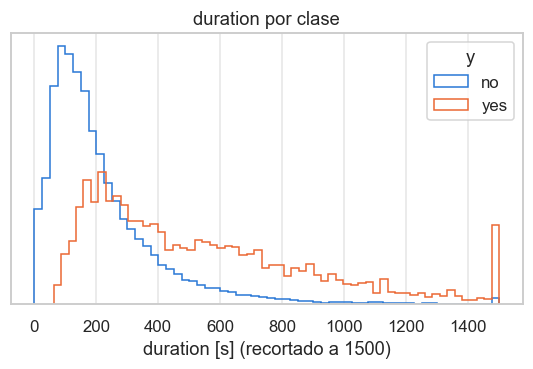

In [12]:
fig, ax = plt.subplots(figsize=(6, 3.2))
for k, lab in [(0, "no"), (1, "yes")]:
    ax.hist(df_train.loc[df_train.y == k, "duration"].clip(upper=1500), bins=60, density=True,
            histtype="step", lw=2, color=plots.CLASS_COLORS[k], label=lab)
ax.set(xlabel="duration [s] (recortado a 1500)", yticks=[], title="duration por clase")
ax.legend(title="y")
plots.save(fig, "eda_duration")
print("mediana duration | no / yes:", df_train.groupby("y").duration.median().tolist())

**Observación:** `duration` separa muy bien las clases (mediana ~2.7× mayor en yes), pero **sólo se conoce cuando la llamada terminó**, momento en el que ya se sabe el resultado. El modelo opera **antes** de llamar.

**Decisión:** **excluir `duration`** (`config.LEAKAGE_COLS`). En 1.7 se cuantifica cuánto "infla" las métricas si se la deja (sólo como referencia).

> Las variables macro (`euribor3m`, etc.) **sí** están disponibles antes de la llamada (son indicadores públicos), por eso se mantienen.

### 1.5 Variables categóricas vs. target

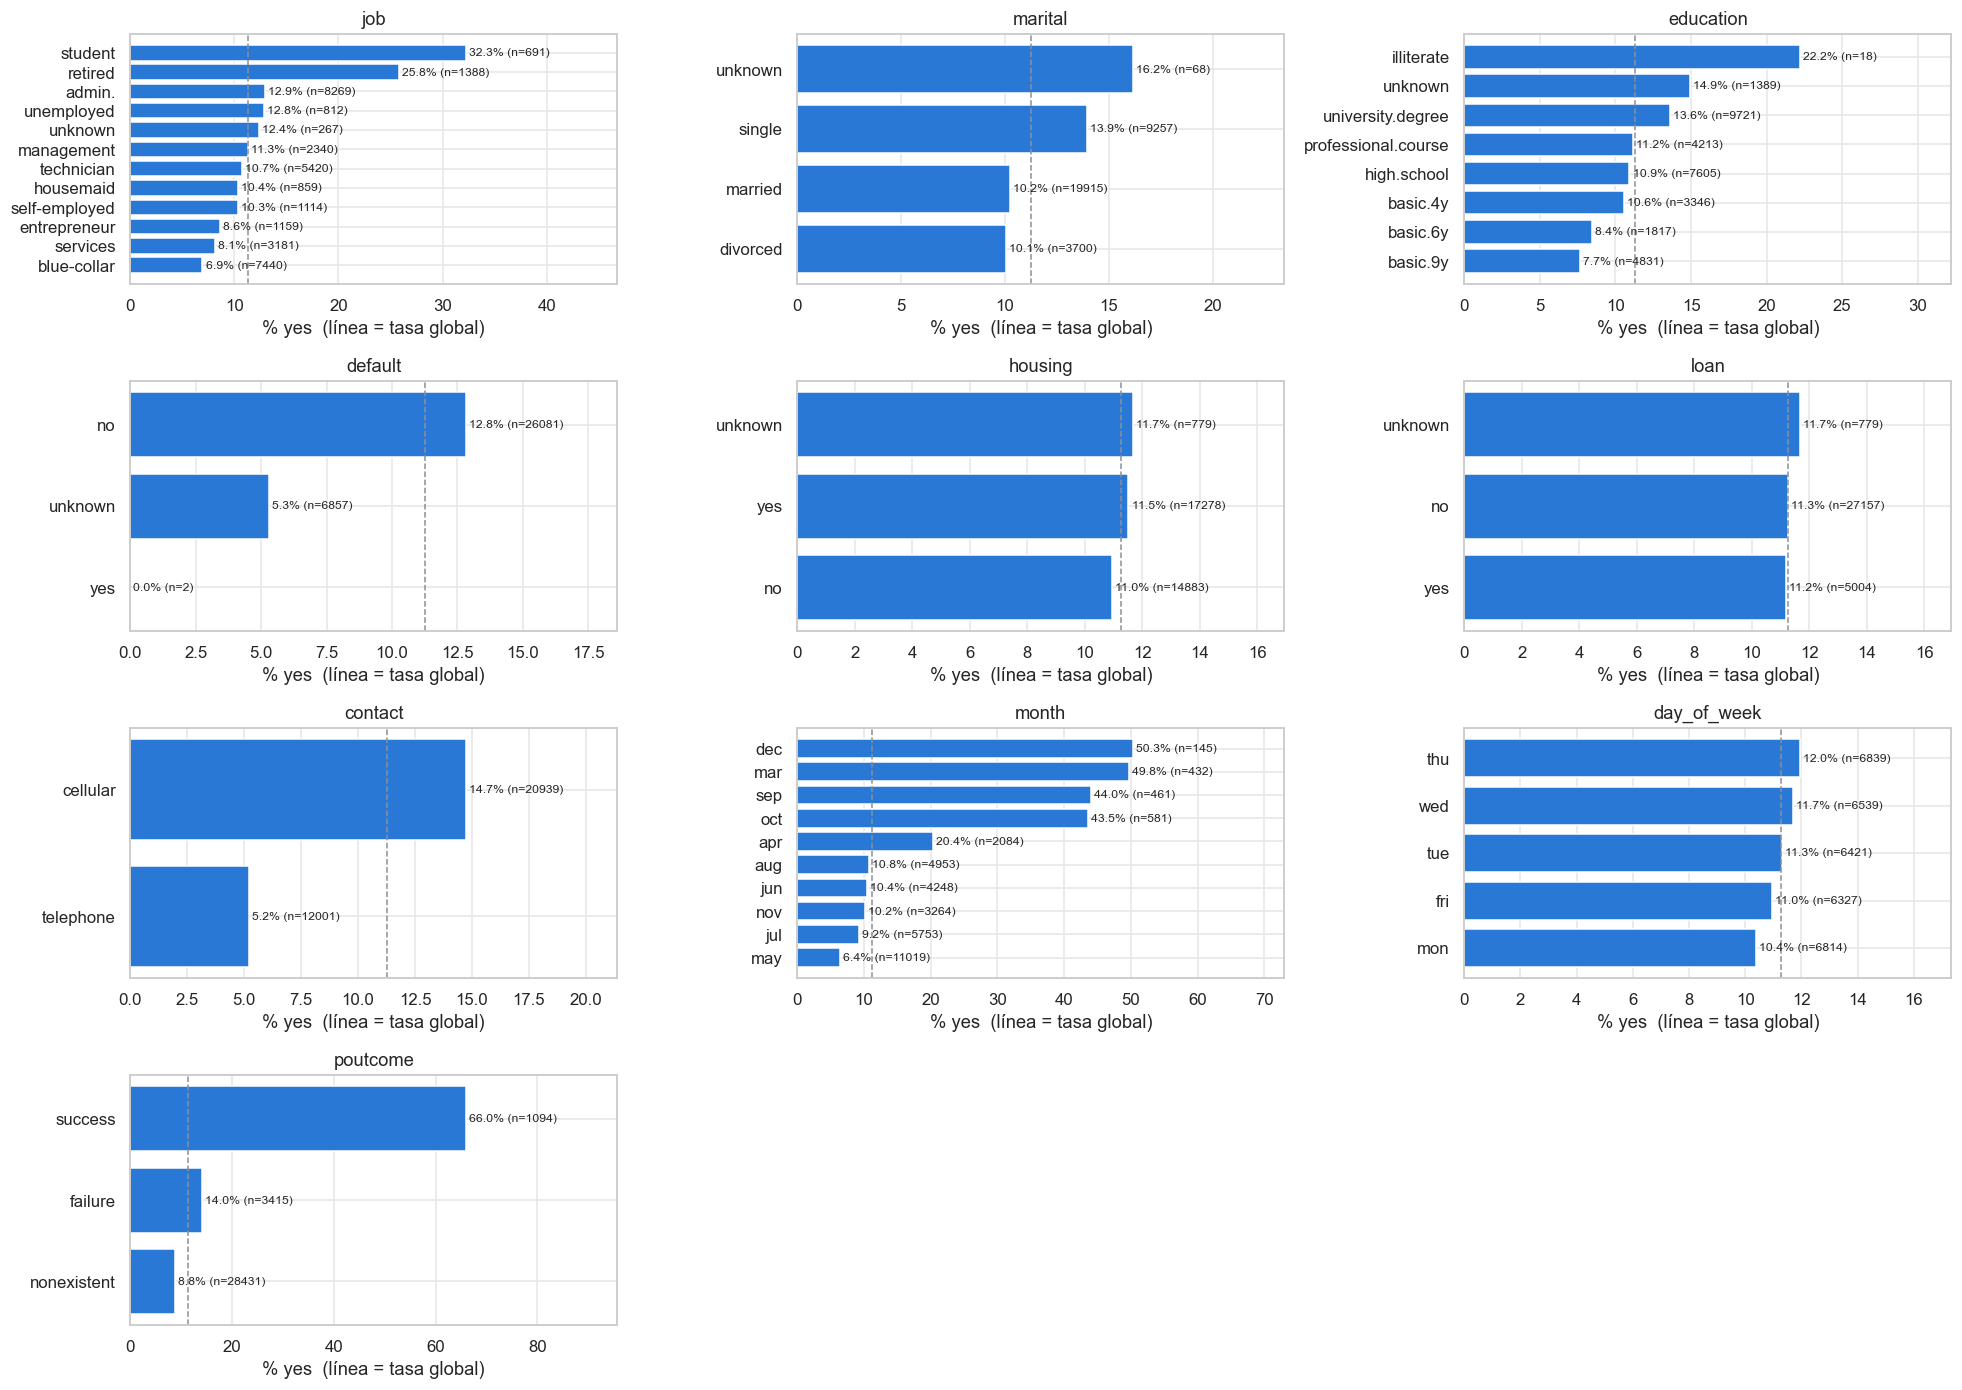

In [13]:
fig = plots.target_rate_grid(df_train, config.CATEGORICAL_COLS, ncols=3)
plots.save(fig, "eda_categoricas")

In [14]:
# Categorías con < 1 % de las filas de train
freq = pd.concat({c: df_train[c].value_counts(normalize=True) for c in config.CATEGORICAL_COLS})
freq[freq < 0.01].mul(100).round(2).rename("% filas").to_frame()

,,% filas
job,unknown,0.81
marital,unknown,0.21
education,illiterate,0.05
default,yes,0.01
month,dec,0.44


**Observaciones**
- **Muy informativas:** `poutcome=success` (~66 % yes), `month` (mar/sep/oct/dec ~45–50 %, pero con pocas filas), `contact` (cellular 14.7 % vs telephone 5.2 %), `job` (student y retired ~2–3× la tasa global).
- **Casi planas:** `housing`, `loan` y `day_of_week` tienen ~11 % de yes en todas sus categorías → poca capacidad discriminante y suman dimensiones (malo para KNN).
- **Categorías raras:** `default=yes` (2 filas), `education=illiterate` (18), `marital=unknown` (~70).
- `month` refleja el **período** de la campaña (el dataset está ordenado por fecha, 2008–2010), no sólo estacionalidad.

**Decisiones:**
- SVM, KNN y RF: **one-hot** de las categóricas, con `min_frequency=0.01`: categorías con < 1 % de train se agrupan en `infrequent`. Como hay a lo sumo una rara por columna, en la práctica sólo la renombra (p. ej. `month=dec`); su valor es que una categoría ausente en un fold (p. ej. `default=yes`, 2 filas) no rompa el pipeline.
- Naive Bayes: usa las categóricas **directamente** con frecuencias relativas y **corrección de Laplace** (clase 6), que evita probabilidades nulas para esas categorías raras.
- Quitar `housing` / `loan` / `day_of_week` se evalúa en 1.7.

### 1.6 Correlaciones

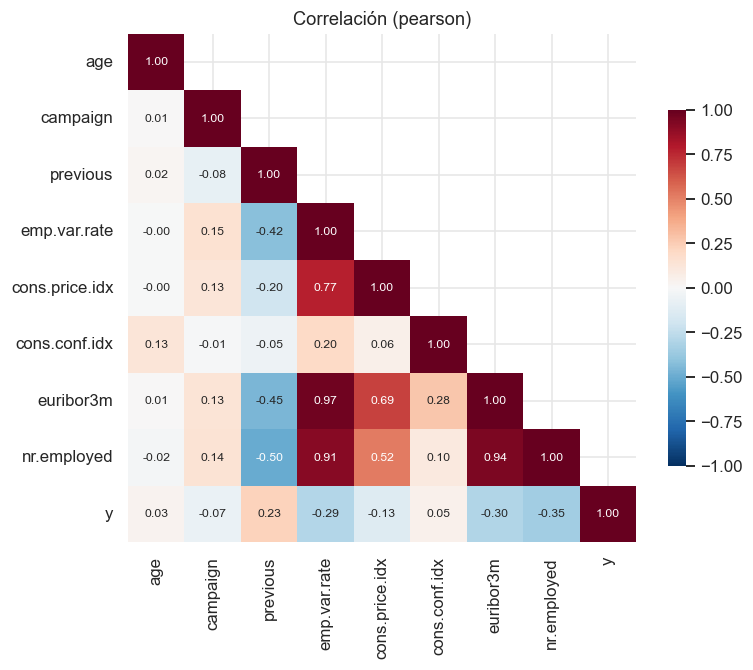

In [15]:
num = [c for c in config.NUMERIC_COLS if c != "pdays"] + ["y"]
fig, ax = plt.subplots(figsize=(7.5, 6))
plots.corr_heatmap(df_train, num, ax=ax)
plots.save(fig, "eda_correlacion")

**Observación:** `emp.var.rate`, `euribor3m` y `nr.employed` tienen correlación de Pearson > 0.9 entre sí: miden lo mismo (el ciclo económico).
- **Naive Bayes** asume independencia condicional → cuenta la misma evidencia 3 veces.
- **KNN** le da el triple de peso a esa dirección en la distancia.
- **RF** no se ve afectado en la predicción (sí reparte la importancia entre ellas).

**Decisión:** probar quitar `emp.var.rate` y `euribor3m` (quedarse con `nr.employed`) en 1.7.

### 1.7 Verificación de las decisiones (k-fold en train)
Las hipótesis del EDA se contrastan con validación cruzada **dentro de train** (el test sigue sin tocarse), con las métricas del punto 2.3: ROC-AUC (principal) y F1.
SVM se omite acá por costo; NB, KNN y RF cubren los tres tipos de supuesto (probabilístico, distancias, árboles).

In [16]:
variants = {
    "base":          {},                                 # sin duration + prev_contacted
    "+duration":     {"keep_leakage": True},             # referencia con leakage
    "-planas":       {"drop": config.FLAT_COLS},
    "-macro_redund": {"drop": config.MACRO_REDUNDANT},
}
make = lambda **kw: models.get_models(only=["NaiveBayes", "KNN", "RF"], **kw)
var_res = ev.compare_variants(variants, make, X_train, y_train)
var_res.assign(v=var_res["mean"].map("{:.3f}".format) + " ± " + var_res["std"].map("{:.3f}".format)) \
       .pivot_table(index=["metric", "model"], columns="variant", values="v", aggfunc="first")

variant                 +duration  -macro_redund        -planas           base
metric  model                                                                 
f1      KNN         0.596 ± 0.011  0.468 ± 0.012  0.471 ± 0.017  0.471 ± 0.012
        NaiveBayes  0.504 ± 0.022  0.429 ± 0.020  0.436 ± 0.021  0.436 ± 0.021
        RF          0.646 ± 0.005  0.498 ± 0.016  0.502 ± 0.014  0.503 ± 0.017
roc_auc KNN         0.914 ± 0.006  0.758 ± 0.007  0.764 ± 0.009  0.759 ± 0.007
        NaiveBayes  0.866 ± 0.008  0.770 ± 0.012  0.772 ± 0.011  0.772 ± 0.011
        RF          0.945 ± 0.003  0.788 ± 0.009  0.795 ± 0.008  0.795 ± 0.008

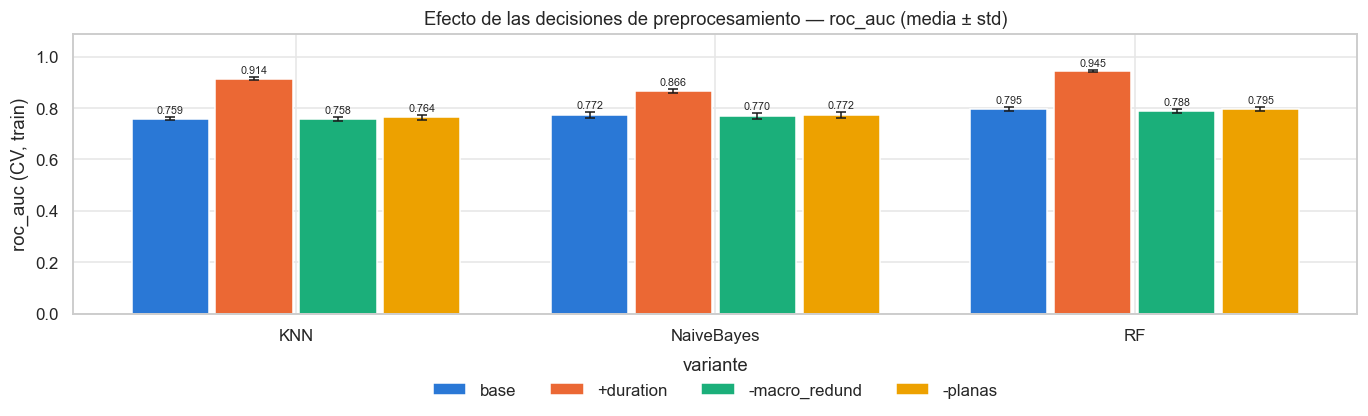

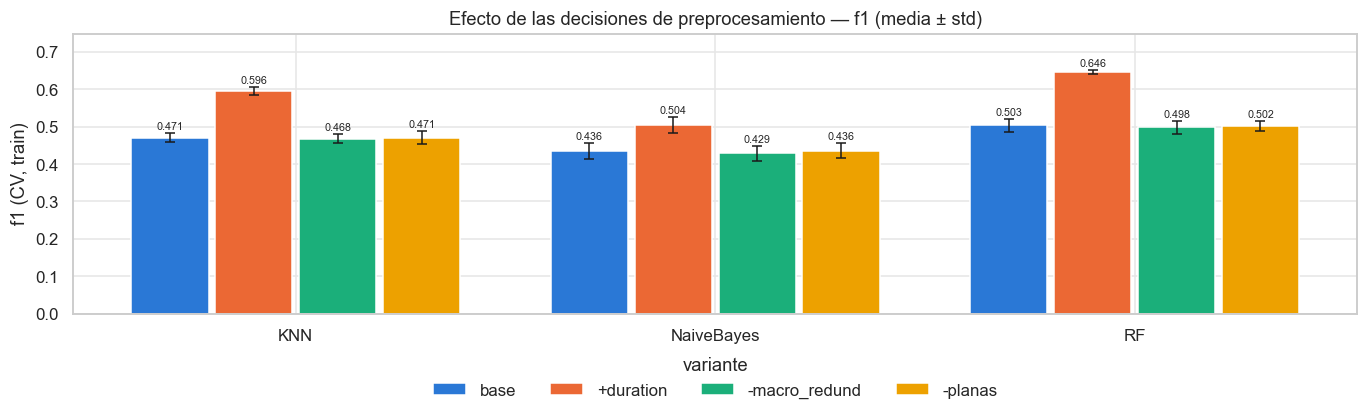

In [17]:
fig = plots.variant_comparison(var_res, "roc_auc")
plots.save(fig, "eda_variantes_auc")
fig = plots.variant_comparison(var_res, "f1")
plots.save(fig, "eda_variantes_f1")

**Lectura** (media ± desvío entre los 5 folds):
- **`+duration`** dispara las métricas (RF: ROC-AUC 0.795 → 0.945; F1 0.503 → 0.646) → confirma el **leakage**: ese rendimiento no existiría al usar el modelo antes de la llamada.
- **`-planas`**: mismo rendimiento en los 3 modelos (diferencias dentro del desvío; KNN +0.005 en AUC) con **3 variables menos** (64 → 53 columnas tras el one-hot). Con el mismo rendimiento se prefiere el modelo más simple: menos dimensiones para las distancias de KNN/SVM y menos cómputo → **se eliminan**.
- **`-macro_redund`**: no mejora y RF empeora levemente (AUC 0.795 → 0.788) → **se mantienen**. RF las aprovecha y el costo para NB/KNN no se nota en las métricas.

### 1.8 Resumen: EDA → pipeline

| Observación (train) | Decisión | Dónde |
|---|---|---|
| 11 % de positivos | Split/k-fold estratificado, sin accuracy, umbral elegido en train | `data.py`, `evaluation.py` |
| `duration` sólo se conoce después de la llamada | Excluida (leakage) | `config.LEAKAGE_COLS` |
| `pdays=999` = "nunca contactado" (96 %) | Variable `prev_contacted` + 999 → -1 | `FeatureEngineer` |
| `unknown` informativo (p. ej. `default`) | Se mantiene como categoría | encoders / NB |
| Categorías raras | `min_frequency=0.01` (one-hot) · Laplace (NB) | `features.py`, `models.py` |
| Escalas muy distintas | z-score para SVM/KNN; RF y NB sin escalar | `make_preprocessor` |
| `housing`/`loan`/`day_of_week` planas | Se eliminan (ver 1.7) | `FE` |
| Macro correlacionadas | Probado en 1.7: sin mejora → se mantienen | 1.7 |
| Transformaciones aprendidas (scaler, encoders) | Dentro del `Pipeline` → se ajustan sólo con el fold de train | `make_pipeline` |

In [18]:
FE = {"drop": config.FLAT_COLS}  # decisión de 1.7: se usa en todo lo que sigue

## 2. Clasificación
**Datos:** sólo `X_train` / `y_train`. El test sigue sin usarse.

### 2.1 Clasificadores (scikit-learn)
Cada modelo es un `Pipeline` completo (`FeatureEngineer` → preprocesamiento → clasificador): cualquier transformación aprendida se ajusta **dentro de cada fold**.

| Modelo | Preprocesamiento | Configuración inicial | Cómo decide (para leer los resultados) |
|---|---|---|---|
| **Naive Bayes** | ninguno | numéricas: gaussiana por clase · categóricas: frecuencias con Laplace (α=1) | P(y\|x) ∝ P(y)·Π P(xᵢ\|y): **independencia condicional** dada la clase |
| **SVM** (`SVC`) | z-score + one-hot | kernel RBF, C=1, γ=`scale` | Hiperplano de margen máximo en el espacio del kernel; `decision_function` = distancia con signo al hiperplano |
| **KNN** | z-score + one-hot | k=15 (impar), sin ponderar | Clase más frecuente entre los k vecinos más cercanos (distancia euclídea) |
| **Random Forest** | one-hot, sin escalar | 300 árboles, `min_samples_leaf=5` | Voto de árboles entrenados con bootstrap y subconjuntos aleatorios de features |

Los hiperparámetros se ajustan en el punto 3; acá se comparan con valores razonables.

In [19]:
mdl = models.get_models(**FE)
mdl["NaiveBayes"]  # ejemplo: pipeline completo

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('fe', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,drop,"['housing', 'loan', ...]"
,pdays_flag,True
,keep_leakage,False
,alpha,1.0


### 2.2 Validación cruzada (k-fold)
- k-fold estratificado (k=5, `shuffle=True`, `random_state=42`) **sobre train**: en cada fold se entrena con ≈26 350 filas y se valida con ≈6 590 (~11.3 % de yes en todos).
- **Mismos folds para los 4 modelos** → se pueden comparar fold a fold.
- En cada fold se guarda el score de validación de cada cliente (probabilidad en NB/KNN/RF, distancia al hiperplano en SVM). Al terminar, **cada fila de train tiene un score de un modelo que no la vio**: con eso se dibuja la curva ROC y se elige el umbral de F1 máximo.
- Costo (2 cores): NB ~1 s, KNN ~15 s, RF ~20 s, **SVM ~2 min** (el SVM con kernel escala mal con n). Queda guardado en `.cache/`.

In [20]:
cv = ev.cv_oof(mdl, X_train, y_train)
folds = cv["folds"]
ev.summarize_oof(folds, ["roc_auc", "f1", "recall", "precision", "%pred_yes", "fit_time"])

metric,roc_auc,f1,recall,precision,%pred_yes,fit_time
model,,,,,,
KNN,0.764 ± 0.009,0.471 ± 0.017,0.529 ± 0.020,0.424 ± 0.016,14.074 ± 0.281,0.376 ± 0.004
NaiveBayes,0.772 ± 0.011,0.436 ± 0.021,0.465 ± 0.026,0.410 ± 0.018,12.766 ± 0.404,0.053 ± 0.002
RF,0.795 ± 0.008,0.502 ± 0.014,0.573 ± 0.019,0.446 ± 0.015,14.463 ± 0.496,8.174 ± 1.317
SVM,0.694 ± 0.008,0.455 ± 0.012,0.439 ± 0.010,0.472 ± 0.019,10.489 ± 0.455,74.208 ± 1.282


### 2.3 Métricas elegidas (clase 4)

**1) ROC-AUC → métrica principal para elegir modelo.**
- El objetivo es **priorizar** a quién llamar: importa que el modelo **ordene** bien a los clientes (los yes arriba). El AUC recorre **todos los umbrales**, así que no depende de cuál elijamos.
- Referencia clara: AUC = 0.5 es un clasificador aleatorio; 1 es ideal.
- Permite comparar modelos con scores en escalas distintas (probabilidades vs. distancia al hiperplano).

**2) F1 → métrica con el umbral de trabajo.**
- Para operar hay que decidir *llamar / no llamar*. F1 combina **precisión** (de los que llamamos, cuántos aceptan) y **recall** (de los que aceptarían, a cuántos llamamos), sin que la dominen los miles de "no" fáciles.
- **Umbral:** con clases desbalanceadas el umbral por defecto (0.5, o `decision_function = 0` en SVM) casi nunca predice "yes" (KNN con k=15 necesita 8 vecinos yes). Como vimos en la clase 4, no hay un umbral correcto universal: se elige según el problema. Acá se elige, para cada modelo, el umbral que **maximiza F1** sobre los scores de validación de la CV (**sólo train**; el test no participa) y ese umbral se fija para el test.
- Si el negocio pesara más los falsos negativos (clientes que habrían aceptado y no se llaman) que las llamadas de más, se bajaría el umbral: más recall, menos precisión (trade-off del umbral, clase 4).

**Descartada:** *accuracy* (decir siempre "no" da 88.7 %).

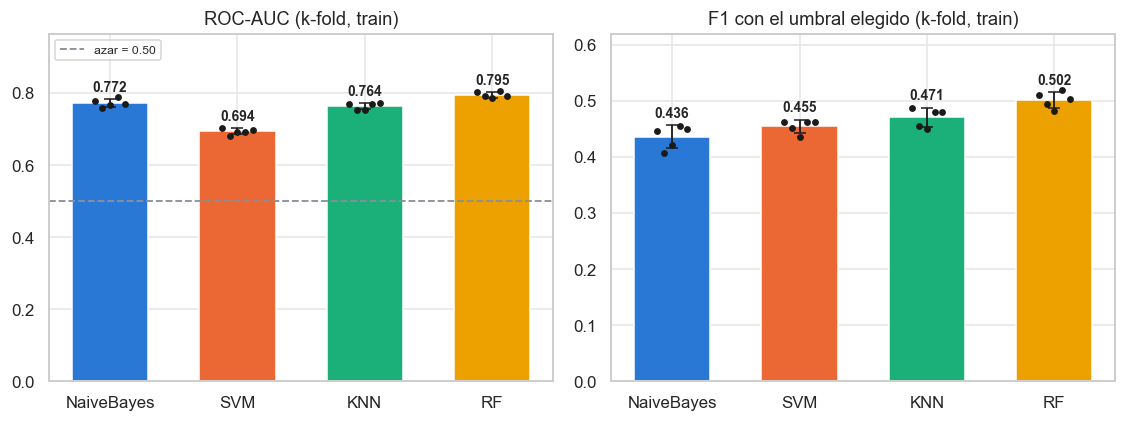

In [21]:
fig = plots.cv_bars(
    folds, ["roc_auc", "f1"],
    baseline={"roc_auc": 0.5},
    titles={"roc_auc": "ROC-AUC (k-fold, train)",
            "f1": "F1 con el umbral elegido (k-fold, train)"},
)
plots.save(fig, "cv_metricas")

,threshold,f1,precision,recall,fpr,tpr
NaiveBayes,0.737,0.436,0.410,0.465,0.085,0.465
SVM,-0.989,0.455,0.472,0.439,0.062,0.439
KNN,0.267,0.471,0.424,0.529,0.091,0.529
RF,0.212,0.502,0.446,0.573,0.090,0.573


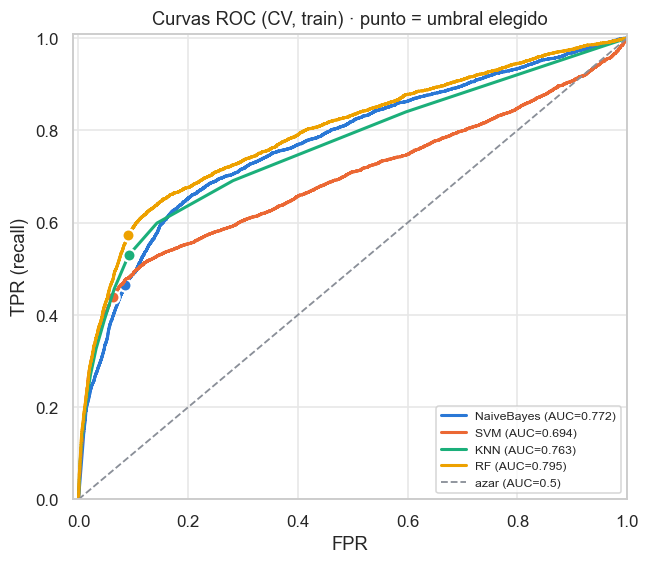

In [22]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
plots.roc_curves_oof(cv["oof"], cv["y"], cv["thresholds"], ax=ax)
plots.save(fig, "cv_curvas_roc")
cv["thresholds"]  # umbral elegido por modelo y su punto de trabajo

metric,%pred_yes@default,recall@default,precision@default
model,,,
KNN,4.982 ± 0.305,0.270 ± 0.014,0.611 ± 0.020
NaiveBayes,16.208 ± 0.636,0.525 ± 0.024,0.365 ± 0.015
RF,4.511 ± 0.304,0.260 ± 0.014,0.649 ± 0.015
SVM,4.366 ± 0.270,0.254 ± 0.012,0.657 ± 0.017


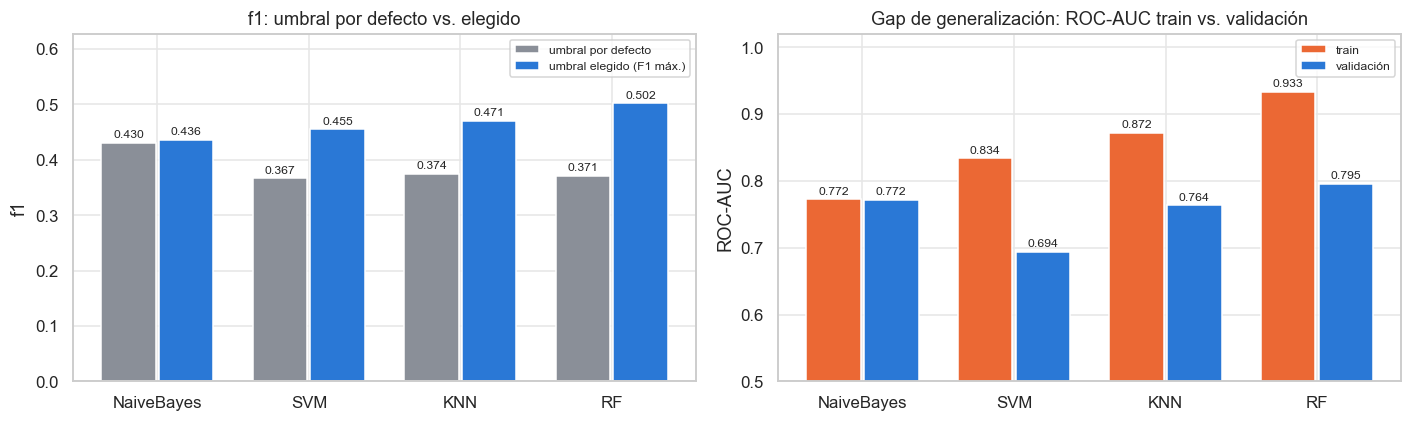

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plots.default_vs_tuned(folds, "f1", ax=axes[0])
plots.train_vs_val(folds, ax=axes[1])
fig.tight_layout()
plots.save(fig, "cv_umbral_y_gap")

# % de clientes que cada modelo marca como "yes" con el umbral por defecto (real: 11.3 %)
ev.summarize_oof(folds, ["%pred_yes@default", "recall@default", "precision@default"])

In [24]:
# Mismos folds para todos -> ¿quién gana en cada fold?
folds[folds.metric == "roc_auc"].pivot(index="fold", columns="model", values="score")

model,KNN,NaiveBayes,RF,SVM
fold,,,,
0,0.769,0.777,0.803,0.704
1,0.753,0.759,0.792,0.682
2,0.754,0.766,0.785,0.692
3,0.769,0.789,0.804,0.692
4,0.771,0.769,0.793,0.698


### 2.4 Lectura de resultados
- **RF es el mejor en las dos métricas**: ROC-AUC 0.795 ± 0.008 (gana en los 5 folds) y F1 0.502 (recall 0.57 y precisión 0.45, llamando al ~14 % de los clientes). Combina muchos árboles, así que captura **no linealidades e interacciones** (edad en U, cortes en `euribor3m`/`nr.employed`, `poutcome` × `prev_contacted`) sin necesitar escalado.
- **Naive Bayes** queda segundo en AUC (0.772) y es el más rápido. Pero sus supuestos no se cumplen: variables macro correlacionadas (ρ>0.9), `prev_contacted` redundante con `poutcome` y numéricas multimodales que no son gaussianas. Por independencia condicional cuenta varias veces la misma evidencia, así que sus **probabilidades quedan extremas**: el umbral óptimo es 0.74 y no 0.5.
- **KNN** (AUC 0.764): con el umbral por defecto marca "yes" sólo al ~5 % de los clientes (recall 0.27). Es el efecto que vimos en clase: **un k alto favorece a la clase mayoritaria**. Eligiendo el umbral (≈4 de 15 vecinos) el F1 pasa de 0.37 a 0.47. Además sufre la **alta dimensionalidad** (53 columnas tras el one-hot, muchas poco informativas) y las 3 macro correlacionadas, que pesan triple en la distancia.
- **SVM** es el más débil en AUC (0.694) y el más lento (~20 s por fit, contra ~4 s de RF). Con 89 % de "no", el margen se acomoda a la clase mayoritaria y muchos clientes quedan con f(x) ≈ −1, casi empatados, así que el **ranking** es pobre (meseta en la curva ROC). En el punto de trabajo su F1 (0.455) es competitivo. C y γ se ajustan en el punto 3.
- **Gap de generalización** (clase 7): RF (0.93 vs 0.80) y KNN (0.87 vs 0.76) tienen la mayor diferencia train/validación, lo que indica algo de **sobreajuste** (se ajusta en el punto 3 con `max_depth` y k). NB casi no tiene gap: es un modelo simple, con **alto sesgo y baja varianza**.
- *Nota:* el F1 de la CV es levemente optimista porque el umbral se eligió con esas mismas predicciones (un solo parámetro). La estimación honesta queda para el test (punto 4), con el umbral fijado en train.

## 3. Ajuste de hiperparámetros (curvas de validación)

In [25]:
# El SVM con kernel escala mal con n: su curva se calcula sobre una submuestra estratificada de train
X_sub, y_sub = data.stratified_subsample(X_train, y_train, n=8000)

vcs = {}
for name, (param, rng) in models.PARAM_RANGES.items():
    Xv, yv = (X_sub, y_sub) if name == "SVM" else (X_train, y_train)
    vcs[name] = ev.val_curve(mdl[name], Xv, yv, param, rng)  # ROC-AUC

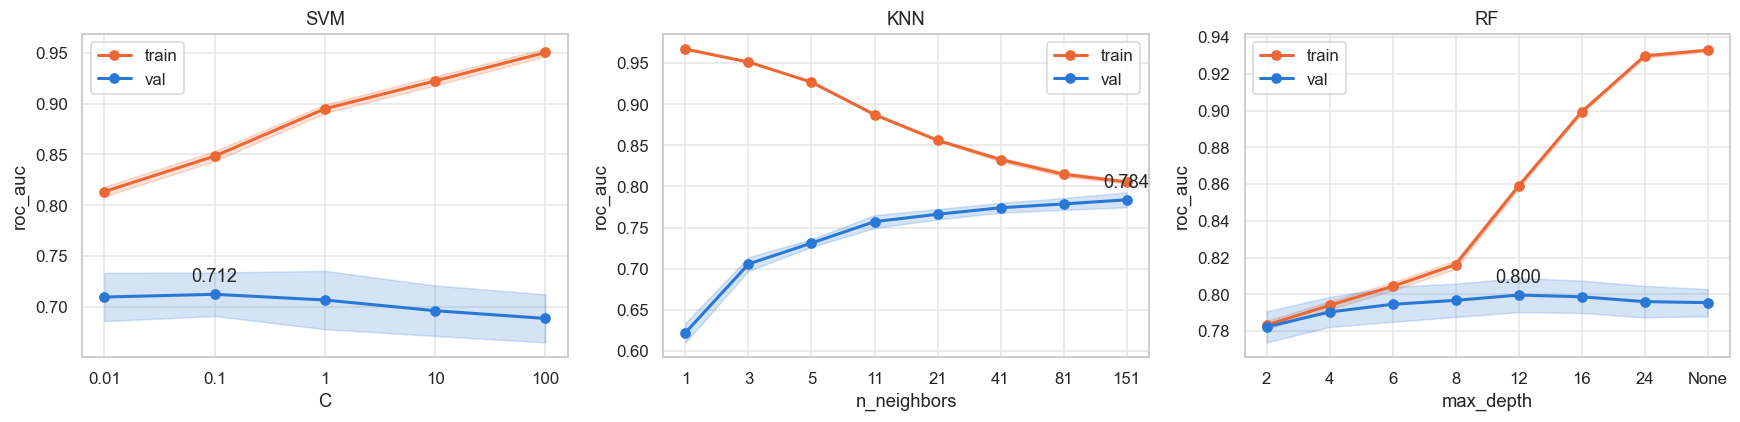

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, vc) in zip(axes, vcs.items()):
    plots.validation_curve(vc, models.PARAM_RANGES[name][0].split("__")[1], ax=ax)
    ax.set_title(name)
fig.tight_layout()

### 3.1 Lectura de las curvas de validación

Las curvas permiten analizar el efecto de los hiperparámetros sobre el **ROC-AUC de train y validación**, y detectar situaciones de subajuste y sobreajuste.

- **SVM `C`:** el mejor resultado de validación se obtiene alrededor de **`C = 0.1`** (ROC-AUC ≈ 0.712). Al aumentar `C`, el ROC-AUC de train continúa creciendo mientras que el de validación disminuye, aumentando el **gap de generalización**. Esto indica que valores altos de `C` producen mayor sobreajuste.

- **KNN `n_neighbors`:** con valores pequeños de `k` se observa un fuerte sobreajuste (para `k = 1`, train ≈ 0.97 frente a validación ≈ 0.62). Al aumentar el número de vecinos, disminuye el rendimiento en train pero mejora progresivamente la validación. El mayor ROC-AUC de validación entre los valores evaluados se obtiene con **`k = 151`** (≈ 0.784), aunque a partir de `k ≈ 41–81` las mejoras son pequeñas, y podría evaluarse uno de esos valores para disminuir el costo computacional.

- **Random Forest `max_depth`:** al aumentar la profundidad, el ROC-AUC de validación mejora hasta aproximadamente **`max_depth = 12`** (≈ 0.800). A partir de allí, el rendimiento de train continúa aumentando mientras que validación se estabiliza o disminuye, evidenciando **sobreajuste**. Por lo tanto, `max_depth = 12` ofrece el mejor compromiso entre capacidad del modelo y generalización.

**Conclusión:** las curvas muestran el compromiso entre complejidad y generalización. Entre los modelos evaluados, **Random Forest con `max_depth = 12` presenta el mayor ROC-AUC de validación (~0.80)**, por lo que se mantiene como principal candidato para el modelo final.

## 4. Modelo final - Random Forest

In [27]:
# TODO: elegir modelo + hiperparámetros, fit en TODO el train, evaluar UNA vez en test
# final = mdl["RF"].set_params(model__max_depth=...)
# thr = ev.cv_oof({"final": final}, X_train, y_train)["thresholds"].loc["final", "threshold"]
# final.fit(X_train, y_train)
# ev.test_report(final, X_test, y_test, threshold=thr)
# plots.final_curves(final, X_test, y_test, threshold=thr);

### 4.1 Optimización de Random Forest

Para mejorar la generalización del Random Forest se evaluan cinco hiperparámetros relevantes:

- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `min_impurity_decrease`
- `n_estimators`

Primero se analizan individualmente mediante **curvas de validación** para identificar zonas de buen rendimiento y controlar el overfitting. Luego, los rangos seleccionados se evaluan conjuntamente mediante **Grid Search**.

In [28]:
# ============================================================
# Curvas de validación - Hiperparámetros de Random Forest
# ============================================================

rf_param_ranges = {
    "model__max_depth": [2, 4, 6, 8, 12, 16, 24, None],
    
    "model__min_samples_split": [2, 5, 10, 20, 40, 80],
    
    "model__min_samples_leaf": [1, 2, 5, 10, 20, 40],
    
    "model__min_impurity_decrease": [0.0, 0.0001, 0.0005, 0.001, 0.005, 0.01],
    
    "model__n_estimators": [50, 100, 200, 300, 500, 800],
}

rf_curves = {}

for param, values in rf_param_ranges.items():
    print(f"Evaluando {param}...")
    
    rf_curves[param] = ev.val_curve(
        mdl["RF"],
        X_train,
        y_train,
        param,
        values
    )

Evaluando model__max_depth...
Evaluando model__min_samples_split...
Evaluando model__min_samples_leaf...
Evaluando model__min_impurity_decrease...
Evaluando model__n_estimators...


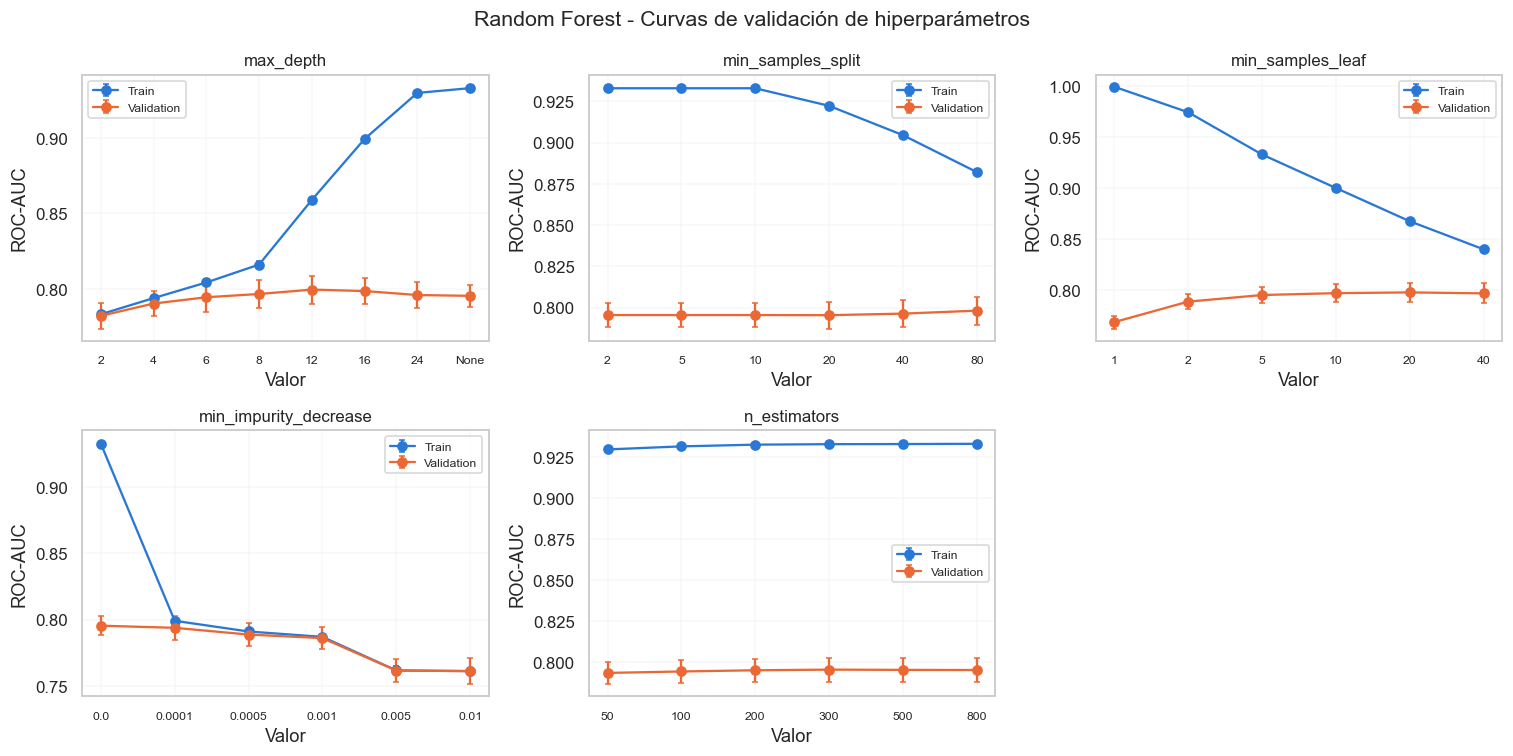

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for ax, (param_name, df) in zip(axes, rf_curves.items()):

    x = range(len(df))

    # Train
    ax.errorbar(
        x,
        df["train_mean"],
        yerr=df["train_std"],
        marker="o",
        capsize=2,
        label="Train"
    )

    # Validation
    ax.errorbar(
        x,
        df["val_mean"],
        yerr=df["val_std"],
        marker="o",
        capsize=2,
        label="Validation"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(df["param"].astype(str), fontsize=8)

    nombre = param_name.replace("model__", "")

    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel("Valor")
    ax.set_ylabel("ROC-AUC")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

# Ocultar el sexto gráfico vacío
for ax in axes[len(rf_curves):]:
    ax.axis("off")

fig.suptitle(
    "Random Forest - Curvas de validación de hiperparámetros",
    fontsize=14
)

plt.tight_layout()
plt.show()

### 4.2 Grid Search - Random Forest

A partir de las curvas de validación se seleccionaron rangos cercanos a las zonas de mejor generalización:

- `max_depth`: **[6, 10, 12, 16]**
- `min_samples_split`: **[20, 80, 120]**
- `min_samples_leaf`: **[5, 20, 40, 50]**
- `min_impurity_decrease`: **[0, 0.0001, 0.001]**

Se deja `n_estimators = 300` fijo, ya que su curva mostró un rendimiento prácticamente constante.

Se utiliza **Grid Search con cross-validation y ROC-AUC** para evaluar las combinaciones y considerar posibles interacciones entre hiperparámetros.

In [35]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    "model__max_depth": [8, 10, 12, 14],
    "model__min_impurity_decrease": [0.0, 0.0001, 0.0005, 0.001],
}

rf_grid = mdl["RF"].set_params(
    model__n_estimators=300,
    model__min_samples_split=80,
    model__min_samples_leaf=20
)

grid_rf = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid_rf,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_rf.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid_rf.best_params_)

print("\nMejor ROC-AUC CV:")
print(grid_rf.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores hiperparámetros:
{'model__max_depth': 14, 'model__min_impurity_decrease': 0.0}

Mejor ROC-AUC CV:
0.7985219309882247


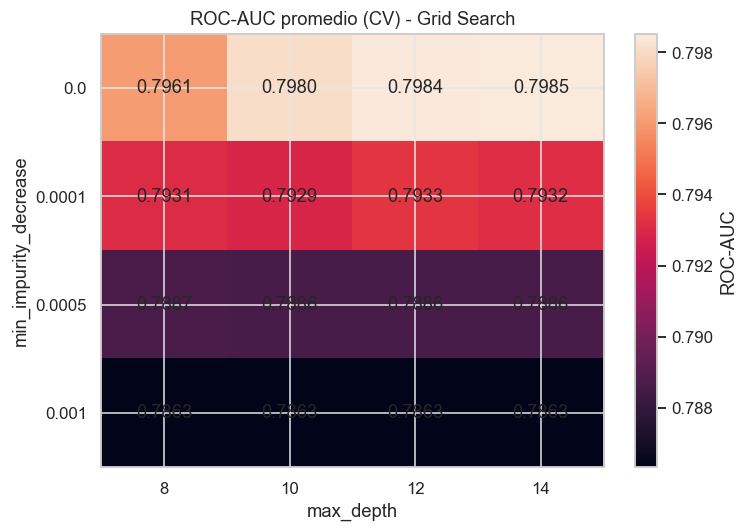

In [39]:
# Heatmap: max_depth × min_impurity_decrease

results = pd.DataFrame(grid_rf.cv_results_)

heatmap_data = results.pivot(
    index="param_model__min_impurity_decrease",
    columns="param_model__max_depth",
    values="mean_test_score"
)

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(heatmap_data.values, aspect="auto")

# Ejes
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.set_xlabel("max_depth")
ax.set_ylabel("min_impurity_decrease")
ax.set_title("ROC-AUC promedio (CV) - Grid Search")

# Valores en cada celda
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]
        ax.text(
            j, i, f"{value:.4f}",
            ha="center", va="center"
        )

plt.colorbar(im, ax=ax, label="ROC-AUC")
plt.tight_layout()
plt.show()

### Refinamiento del Grid Search

Con `min_samples_split = 80` y `min_samples_leaf = 20`, el mejor resultado se obtuvo con `min_impurity_decrease = 0`.

El heatmap muestra que, para todas las profundidades evaluadas, aumentar `min_impurity_decrease` produce una disminución prácticamente monótona del ROC-AUC. Esto sugiere que imponer una restricción adicional sobre la reducción de impureza no mejora la generalización en esta configuración, probablemente porque las restricciones basadas en cantidad de muestras ya aportan suficiente regularización.

Por ello, se fija `min_impurity_decrease = 0` y se analiza la interacción entre `max_depth` y `min_samples_leaf`, manteniendo los demás parámetros fijos.

In [36]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    "model__max_depth": [8, 10, 12, 14],
    "model__min_samples_leaf": [5, 10, 20, 40],
}

rf_grid = mdl["RF"].set_params(
    model__n_estimators=300,
    model__min_samples_split=80,
    model__min_impurity_decrease=0.0
)

grid_rf_final = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid_rf,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_rf_final.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid_rf_final.best_params_)

print("\nMejor ROC-AUC CV:")
print(grid_rf_final.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores hiperparámetros:
{'model__max_depth': 14, 'model__min_samples_leaf': 5}

Mejor ROC-AUC CV:
0.7986727618401522


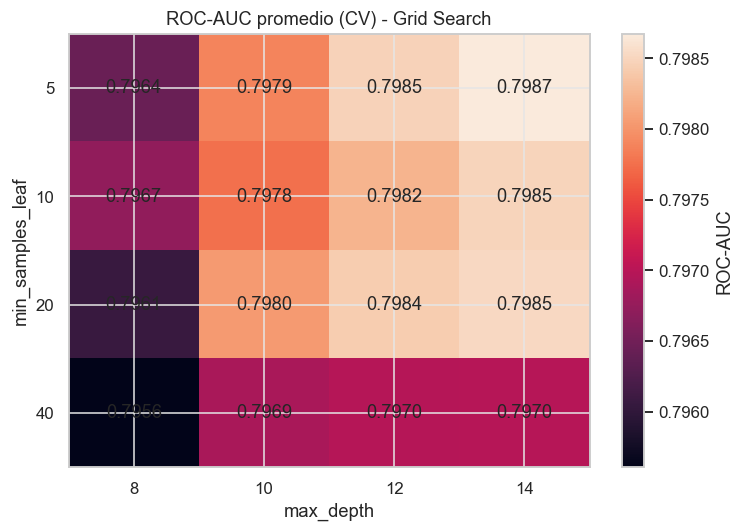

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Resultados del Grid Search max_depth × min_samples_leaf
results = pd.DataFrame(grid_rf_final.cv_results_)

# Matriz para el heatmap
heatmap_data = results.pivot(
    index="param_model__min_samples_leaf",
    columns="param_model__max_depth",
    values="mean_test_score"
)

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(heatmap_data.values, aspect="auto")

# Ejes
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.set_xlabel("max_depth")
ax.set_ylabel("min_samples_leaf")
ax.set_title("ROC-AUC promedio (CV) - Grid Search")

# Valor dentro de cada celda
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]
        ax.text(
            j, i, f"{value:.4f}",
            ha="center", va="center"
        )

plt.colorbar(im, ax=ax, label="ROC-AUC")
plt.tight_layout()
plt.show()

### Selección final de hiperparámetros

El Grid Search muestra una región de rendimiento estable para profundidades entre 12 y 14 y valores de `min_samples_leaf` entre 5 y 20.

La mejor combinación evaluada fue:

- `max_depth = 14`
- `min_samples_leaf = 5`
- `min_samples_split = 80`
- `min_impurity_decrease = 0`
- `n_estimators = 300`

con un ROC-AUC promedio de validación cercano a **0.799**.

La mejora respecto del modelo inicial es pequeña y varias configuraciones presentan resultados muy similares, por lo que no se observa un óptimo fuertemente marcado. Sin embargo, el análisis permitió identificar una zona estable de buen rendimiento y controlar el sobreajuste observado inicialmente.

### 4.3 Elección de threshold con F1

In [40]:
# Modelo final con los hiperparámetros seleccionados
final = mdl["RF"].set_params(
    model__n_estimators=300,
    model__max_depth=14,
    model__min_samples_split=80,
    model__min_samples_leaf=5,
    model__min_impurity_decrease=0.0
)

# Elegir threshold usando únicamente el train mediante CV
oof_final = ev.cv_oof(
    {"final": final},
    X_train,
    y_train
)

threshold_final = oof_final["thresholds"].loc["final", "threshold"]

print(f"Threshold seleccionado: {threshold_final:.3f}")

Threshold seleccionado: 0.221


### Selección del threshold

El threshold se seleccionó utilizando únicamente el conjunto de entrenamiento mediante predicciones out-of-fold.

Se obtuvo un valor de **0.221**, por lo que se clasifica como `yes` a los casos con una probabilidad estimada mayor o igual a este valor.

El umbral es menor a 0.5 debido al desbalance de clases y busca un mejor compromiso entre **precision y recall**, maximizando el **F1-score**. Este threshold queda fijado antes de evaluar el modelo sobre test.

### 4.4 Entrenamiento y estimación de performance en datos nuevos

TRAIN
ROC-AUC: 0.850
F1:      0.513

TEST
ROC-AUC: 0.811
F1:      0.525


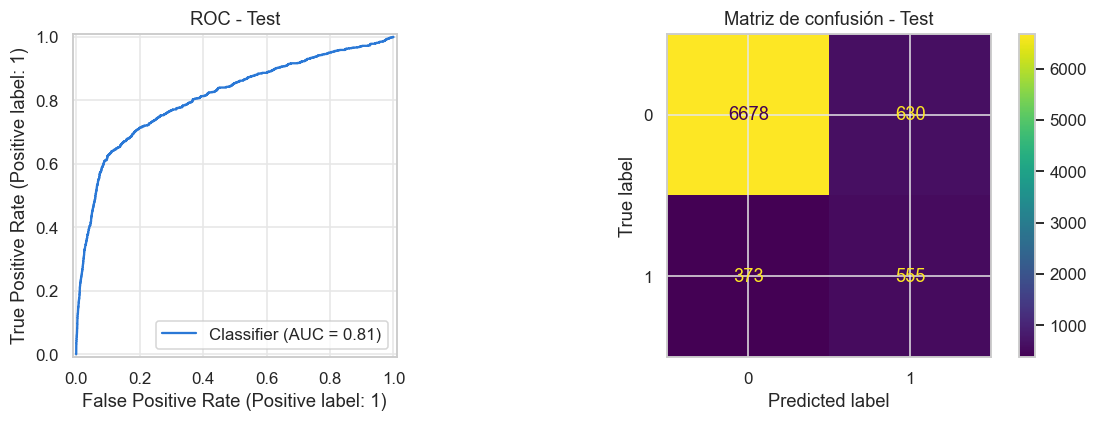

In [43]:
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Entrenar modelo final con TODO el train
final.fit(X_train, y_train)

# 2. Métricas en TRAIN
proba_train = final.predict_proba(X_train)[:, 1]
pred_train = (proba_train >= threshold_final).astype(int)

auc_train = roc_auc_score(y_train, proba_train)
f1_train = f1_score(y_train, pred_train)

# 3. Métricas en TEST
proba_test = final.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= threshold_final).astype(int)

auc_test = roc_auc_score(y_test, proba_test)
f1_test = f1_score(y_test, pred_test)

# 4. Mostrar métricas
print("TRAIN")
print(f"ROC-AUC: {auc_train:.3f}")
print(f"F1:      {f1_train:.3f}")

print("\nTEST")
print(f"ROC-AUC: {auc_test:.3f}")
print(f"F1:      {f1_test:.3f}")

# 5. Una sola figura de evaluación en TEST
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

RocCurveDisplay.from_predictions(
    y_test,
    proba_test,
    ax=axes[0]
)
axes[0].set_title("ROC - Test")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_test,
    ax=axes[1]
)
axes[1].set_title("Matriz de confusión - Test")

plt.tight_layout()
plt.show()

## 5. Conclusiones
- Qué modelo funcionó mejor y por qué (relación con EDA y supuestos de cada algoritmo)
- Supuestos: NB (independencia, gaussianidad), KNN/SVM (escala, dimensionalidad del one-hot), RF
- Errores más costosos (FN vs FP) y limitaciones
- Mejoras